<a href="https://colab.research.google.com/github/zemand/r_d-computer-vision-course/blob/main/Homework-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOMEWORK 3

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USM)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [8]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

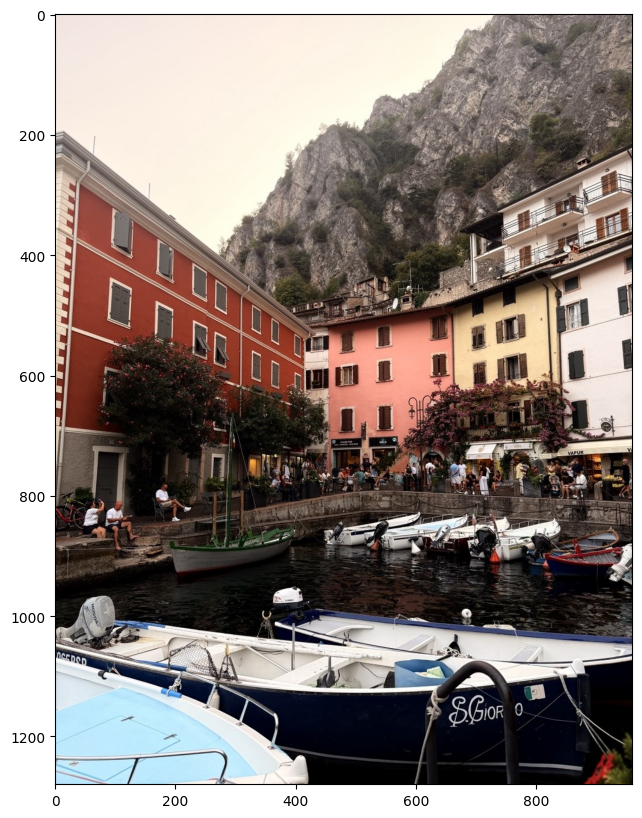

In [9]:
img = cv2.imread('mypic.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

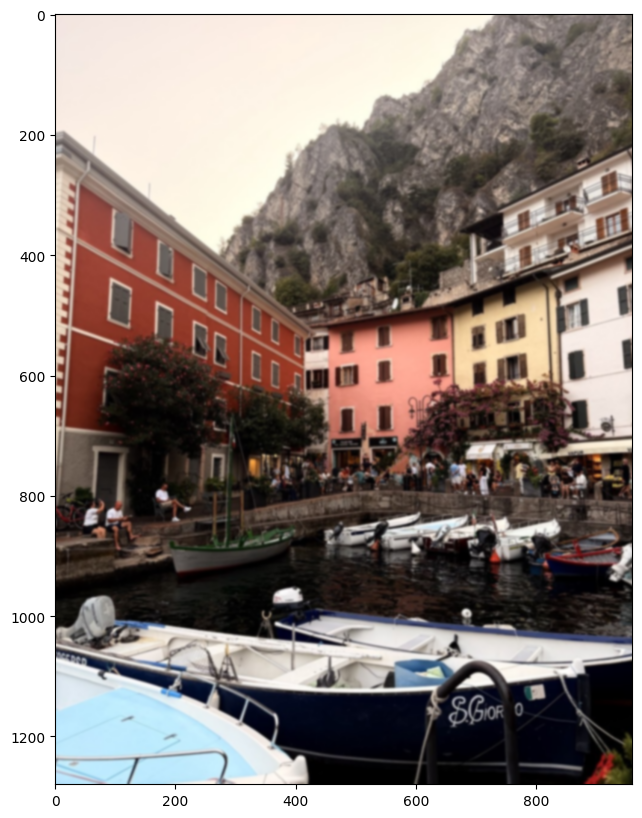

In [10]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, (9, 9), 0)

plt.imshow(unsharp)

In [11]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = img.astype(np.float32) - unsharp.astype(np.float32)

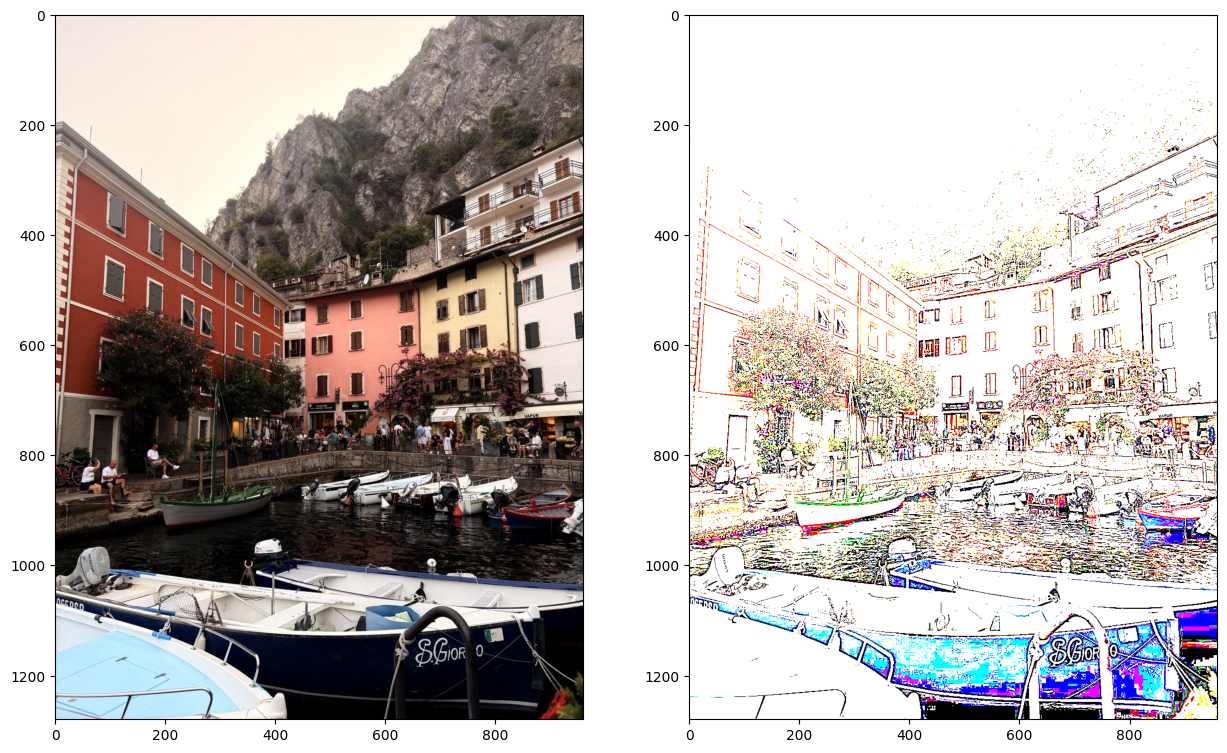

In [12]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.
sharpened = img.astype(np.float32) + diff * 1.5

# Show the original and the sharpened image side by side
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(sharpened)
plt.show()

### Questions
* What is a good (reasonable) value for the `amount` parameter?
Зазвичай в діапазоні від 0.5 до 1.5 для збільшення чіткості.

---

 * What happens if it is too small?
 При малому значенні майже не буде якогось ефекту в порівнянні з оригіналом.


---


 * What happens if it is too large?
 На контурах об'єктів з'являються чорні та білі лінії + додається шум на зображенні.